In [1]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
results_df = pd.read_csv("D://USF//Semester III - Fall 2024//Topics in NLP//Research - TNLP//llm_income_prediction_analysis_1000.csv")

In [3]:
print(results_df.columns)

Index(['Year', 'State', 'Model', 'Response', 'Actual_Label', 'Gender', 'AGEP',
       'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P',
       'PINCP'],
      dtype='object')


In [4]:
results_df.head()

,Year,State,Model,Response,Actual_Label,Gender,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,2014,CA,ChatGPT,Below,Below,Male,30.0,1.0,22.0,1.0,4850.0,515.0,0.0,40.0,1.0,1.0,1200.0
1,2014,CA,Claude,Below,Below,Male,30.0,1.0,22.0,1.0,4850.0,515.0,0.0,40.0,1.0,1.0,1200.0
2,2014,CA,Mistral,Above,Below,Male,30.0,1.0,22.0,1.0,4850.0,515.0,0.0,40.0,1.0,1.0,1200.0
3,2014,CA,ChatGPT,Below,Below,Female,40.0,4.0,22.0,5.0,2200.0,6.0,2.0,10.0,2.0,1.0,NaN
4,2014,CA,Claude,Below,Below,Female,40.0,4.0,22.0,5.0,2200.0,6.0,2.0,10.0,2.0,1.0,NaN


In [5]:
response_check = results_df.groupby(['Year', 'State', 'PINCP'])[['Model', 'Response']].agg(lambda x: len(x.unique()))
print("Number of unique responses per case:")
print(response_check)

Number of unique responses per case:
                      Model  Response
Year State PINCP                     
2014 CA    -5400.0        3         1
            0.0           3         3
            4.0           3         2
            180.0         3         2
            200.0         3         2
...                     ...       ...
2018 TX     351000.0      3         2
            379000.0      3         1
            468000.0      3         2
            473000.0      3         2
            474000.0      3         2

[3164 rows x 2 columns]


In [6]:
sample_check = results_df.groupby(['Year', 'State', 'PINCP', 'Actual_Label'])[['Model', 'Response']].head(10)
print("\nSample predictions across models:")
print(sample_check)


Sample predictions across models:
         Model Response
0      ChatGPT    Below
1       Claude    Below
2      Mistral    Above
6      ChatGPT    Below
7       Claude    Above
...        ...      ...
26995   Claude    Below
26996  Mistral    Above
26997  ChatGPT    Below
26998   Claude    Below
26999  Mistral    Below

[17084 rows x 2 columns]


In [7]:
def check_prediction_diversity():
    for year in results_df['Year'].unique():
        for state in results_df['State'].unique():
            sample = results_df[
                (results_df['Year'] == year) & 
                (results_df['State'] == state)
            ].groupby('PINCP')[['Model', 'Response']].agg(set)
            
            if len(sample) > 0:
                print(f"\nYear: {year}, State: {state}")
                print(sample.head())

In [8]:
check_prediction_diversity()


Year: 2014, State: CA
                              Model                 Response
PINCP                                                       
-5400.0  {Claude, ChatGPT, Mistral}                  {Above}
 0.0     {Claude, ChatGPT, Mistral}  {Above, Unknown, Below}
 4.0     {Claude, ChatGPT, Mistral}           {Above, Below}
 180.0   {Claude, ChatGPT, Mistral}           {Above, Below}
 200.0   {Claude, ChatGPT, Mistral}           {Above, Below}

Year: 2014, State: TX
                            Model        Response
PINCP                                            
0.0    {Claude, ChatGPT, Mistral}  {Above, Below}
20.0   {Claude, ChatGPT, Mistral}  {Above, Below}
40.0   {Claude, ChatGPT, Mistral}         {Below}
90.0   {Claude, ChatGPT, Mistral}         {Below}
180.0  {Claude, ChatGPT, Mistral}  {Above, Below}

Year: 2014, State: MI
                            Model        Response
PINCP                                            
0.0    {Claude, ChatGPT, Mistral}  {Above, Below}
150.

In [9]:
response_dist = pd.crosstab(
    [results_df['Year'], results_df['State'], results_df['Model']], 
    results_df['Response']
)
print("\nResponse distribution across models:")
print(response_dist)


Response distribution across models:
Response            Above  Below  Unknown
Year State Model                         
2014 CA    ChatGPT    320    680        0
           Claude     124    876        0
           Mistral    792    206        2
     MI    ChatGPT    275    725        0
           Claude     114    879        7
           Mistral    719    281        0
     TX    ChatGPT    322    678        0
           Claude     144    856        0
           Mistral    783    215        2
2016 CA    ChatGPT    313    687        0
           Claude     136    864        0
           Mistral    786    211        3
     MI    ChatGPT    292    708        0
           Claude     122    875        3
           Mistral    746    253        1
     TX    ChatGPT    328    672        0
           Claude     152    848        0
           Mistral    808    189        3
2018 CA    ChatGPT    315    685        0
           Claude     134    866        0
           Mistral    757    240      

#### 1. Distribution of predictions across models, years, and states

In [10]:
model_distribution = pd.crosstab(
    [results_df['Year'], results_df['State']], 
    results_df['Model']
)

In [11]:
print("Distribution of predictions across models, years, and states:")
print(model_distribution)
print("\n" + "="*80 + "\n")

Distribution of predictions across models, years, and states:
Model       ChatGPT  Claude  Mistral
Year State                          
2014 CA        1000    1000     1000
     MI        1000    1000     1000
     TX        1000    1000     1000
2016 CA        1000    1000     1000
     MI        1000    1000     1000
     TX        1000    1000     1000
2018 CA        1000    1000     1000
     MI        1000    1000     1000
     TX        1000    1000     1000




#### 2. Accuracy of predictions across models, years, and states

In [12]:
results_df['Is_Correct'] = results_df['Response'] == results_df['Actual_Label']

In [13]:
accuracy_analysis = results_df.groupby(['Year', 'State', 'Model'])['Is_Correct'].agg([
    'count',
    'mean'
]).round(3)

In [14]:
print("Accuracy Analysis by Model, Year, and State:")
print(accuracy_analysis)
print("\n" + "="*80 + "\n")

Accuracy Analysis by Model, Year, and State:
                    count   mean
Year State Model                
2014 CA    ChatGPT   1000  0.649
           Claude    1000  0.681
           Mistral   1000  0.550
     MI    ChatGPT   1000  0.725
           Claude    1000  0.753
           Mistral   1000  0.517
     TX    ChatGPT   1000  0.693
           Claude    1000  0.743
           Mistral   1000  0.484
2016 CA    ChatGPT   1000  0.644
           Claude    1000  0.655
           Mistral   1000  0.546
     MI    ChatGPT   1000  0.704
           Claude    1000  0.734
           Mistral   1000  0.488
     TX    ChatGPT   1000  0.651
           Claude    1000  0.681
           Mistral   1000  0.505
2018 CA    ChatGPT   1000  0.663
           Claude    1000  0.660
           Mistral   1000  0.579
     MI    ChatGPT   1000  0.679
           Claude    1000  0.695
           Mistral   1000  0.508
     TX    ChatGPT   1000  0.685
           Claude    1000  0.689
           Mistral   1000  0.52

#### 3. Race Distribution by Year and State

In [15]:
race_mapping = {
    1: 'White',
    2: 'Black',
    3: 'American Indian',
    4: 'Alaska Native',
    5: 'American Indian and Alaska Native',
    6: 'Asian',
    7: 'Native Hawaiian and Pacific Islander',
    8: 'Other',
    9: 'Multiple Races'
}

In [16]:
results_df['Race'] = results_df['RAC1P'].map(race_mapping)

In [17]:
race_distribution = pd.crosstab(
    [results_df['Year'], results_df['State']], 
    results_df['Race'], 
    normalize='index'
).round(3)

In [18]:
print("Race Distribution by Year and State (proportions):")
print(race_distribution)
print("\n" + "="*80 + "\n")

Race Distribution by Year and State (proportions):
Race        American Indian  American Indian and Alaska Native  Asian  Black  \
Year State                                                                     
2014 CA               0.013                              0.007  0.154  0.041   
     MI               0.004                              0.001  0.021  0.078   
     TX               0.001                              0.001  0.031  0.100   
2016 CA               0.010                              0.001  0.160  0.043   
     MI               0.007                              0.000  0.028  0.100   
     TX               0.009                              0.001  0.047  0.092   
2018 CA               0.004                              0.003  0.157  0.046   
     MI               0.003                              0.000  0.025  0.067   
     TX               0.002                              0.004  0.050  0.095   

Race        Multiple Races  Native Hawaiian and Pacific Islander  Ot

In [19]:
gender_accuracy = results_df.groupby(['Year', 'State', 'Gender'])['Is_Correct'].agg([
    'count',
    'mean'
]).round(3)

In [20]:
print("Accuracy Analysis by Gender:")
print(gender_accuracy)
print("\n" + "="*80 + "\n")

Accuracy Analysis by Gender:
                   count   mean
Year State Gender              
2014 CA    Female   1353  0.606
           Male     1647  0.644
     MI    Female   1479  0.688
           Male     1521  0.642
     TX    Female   1410  0.652
           Male     1590  0.629
2016 CA    Female   1332  0.604
           Male     1668  0.624
     MI    Female   1398  0.675
           Male     1602  0.614
     TX    Female   1425  0.632
           Male     1575  0.594
2018 CA    Female   1353  0.615
           Male     1647  0.650
     MI    Female   1473  0.643
           Male     1527  0.612
     TX    Female   1362  0.657
           Male     1638  0.612




#### 5. Visualization of key metrics

In [21]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Accuracy')

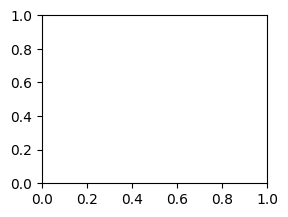

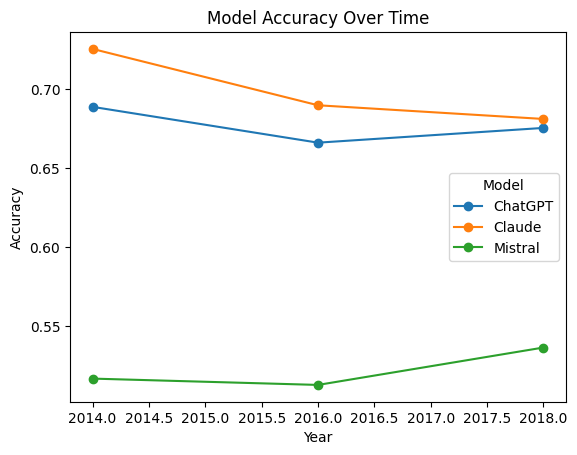

In [22]:
plt.subplot(2, 2, 1)
accuracy_by_model_year = results_df.groupby(['Year', 'Model'])['Is_Correct'].mean()
accuracy_by_model_year.unstack().plot(marker='o')
plt.title('Model Accuracy Over Time')
plt.ylabel('Accuracy')

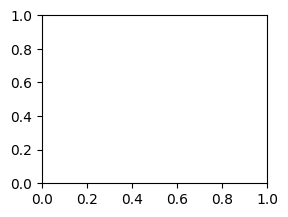

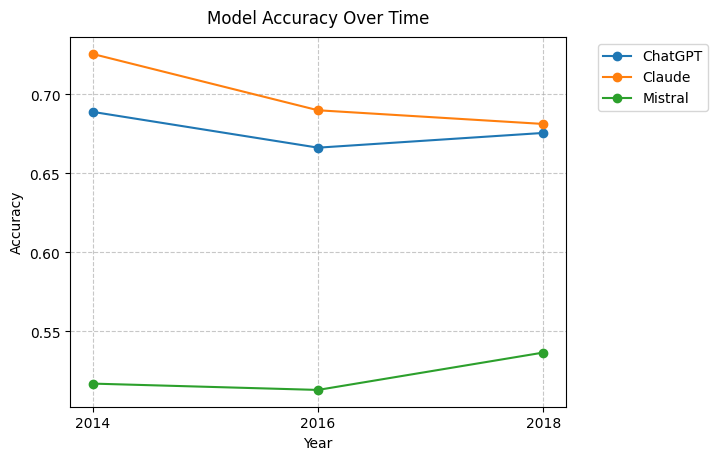

In [23]:
plt.subplot(2, 2, 1)

years_to_show = [2014, 2016, 2018]
filtered_df = results_df[results_df['Year'].isin(years_to_show)]

accuracy_by_model_year = filtered_df.groupby(['Year', 'Model'])['Is_Correct'].mean()
accuracy_by_model_year.unstack().plot(marker='o')

plt.title('Model Accuracy Over Time', fontsize=12, pad=10)
plt.ylabel('Accuracy')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(years_to_show)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [24]:
accuracy_by_model_year 

Year  Model  
2014  ChatGPT    0.689000
      Claude     0.725667
      Mistral    0.517000
2016  ChatGPT    0.666333
      Claude     0.690000
      Mistral    0.513000
2018  ChatGPT    0.675667
      Claude     0.681333
      Mistral    0.536667
Name: Is_Correct, dtype: float64

Text(0, 0.5, 'Count')

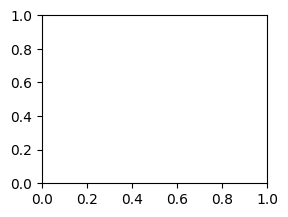

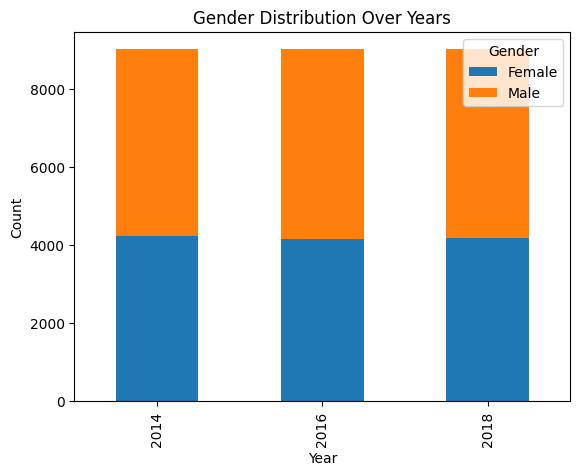

In [25]:
plt.subplot(2, 2, 2)
gender_dist = results_df.groupby(['Year', 'Gender']).size().unstack()
gender_dist.plot(kind='bar', stacked=True)
plt.title('Gender Distribution Over Years')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

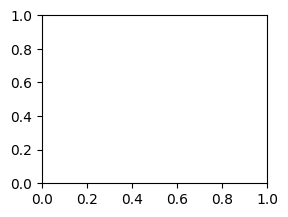

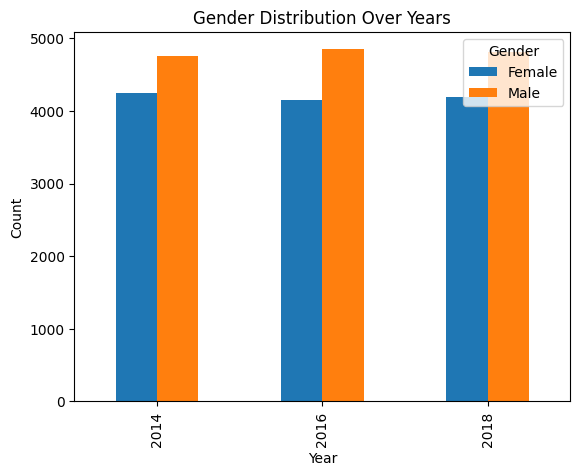

In [26]:
plt.subplot(2, 2, 2)
gender_dist = results_df.groupby(['Year', 'Gender']).size().unstack()
gender_dist.plot(kind='bar', stacked=False)
plt.title('Gender Distribution Over Years')
plt.ylabel('Count')

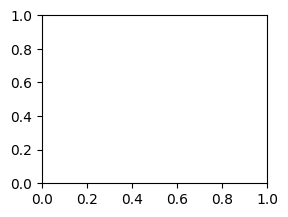

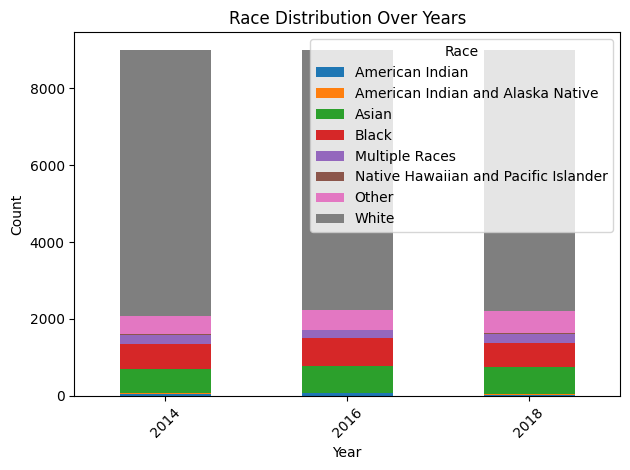

In [27]:
plt.subplot(2, 2, 3)
race_dist = results_df.groupby(['Year', 'Race']).size().unstack()
race_dist.plot(kind='bar', stacked=True)
plt.title('Race Distribution Over Years')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


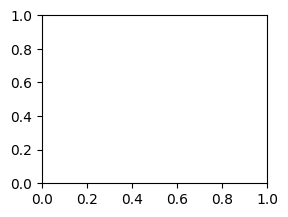

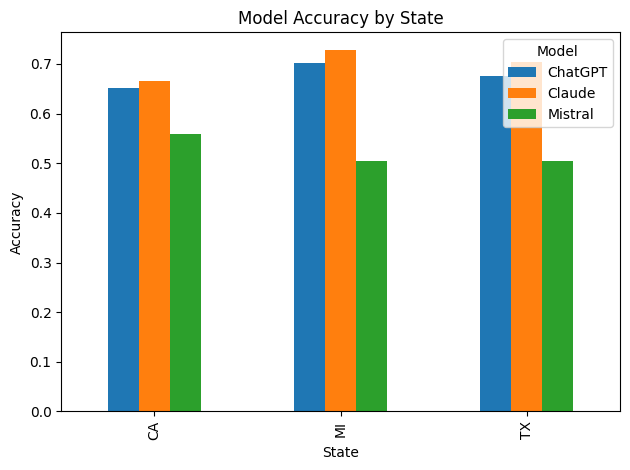

In [28]:
plt.subplot(2, 2, 2)
gender_dist = results_df.groupby(['Year', 'Gender']).size().unstack()
gender_dist.plot(kind='bar', stacked=True)
plt.title('Gender Distribution Over Years')
plt.ylabel('Count')


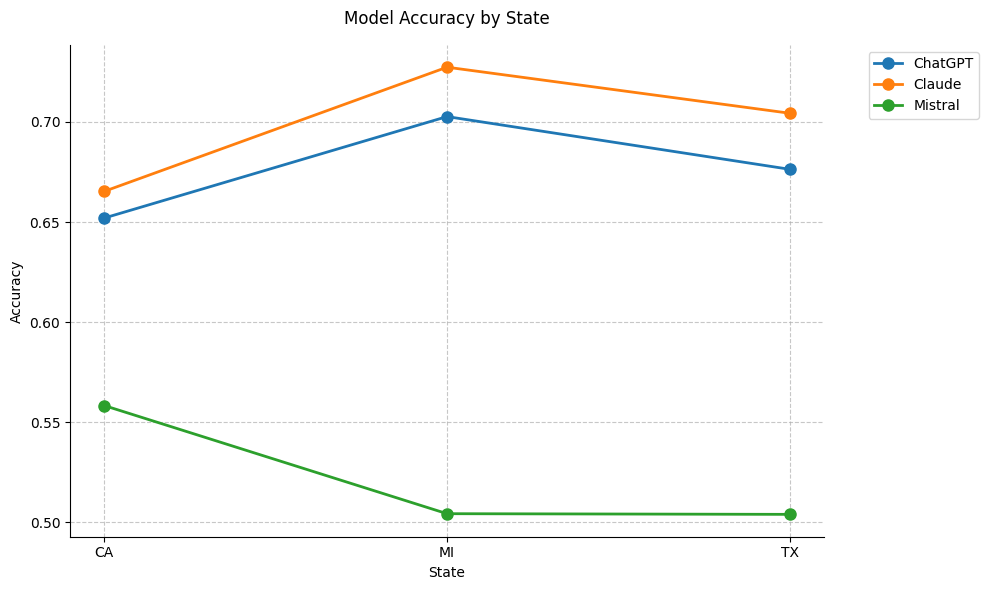

In [29]:
plt.figure(figsize=(10, 6))

state_accuracy = results_df.groupby(['State', 'Model'])['Is_Correct'].mean().unstack()

for model in state_accuracy.columns:
    plt.plot(state_accuracy.index, state_accuracy[model], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=model)

plt.title('Model Accuracy by State', fontsize=12, pad=15)
plt.xlabel('State', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

colors = {
    'ChatGPT': '#2ecc71',
    'Claude': '#3498db',
    'Mistral': '#e74c3c'
}

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

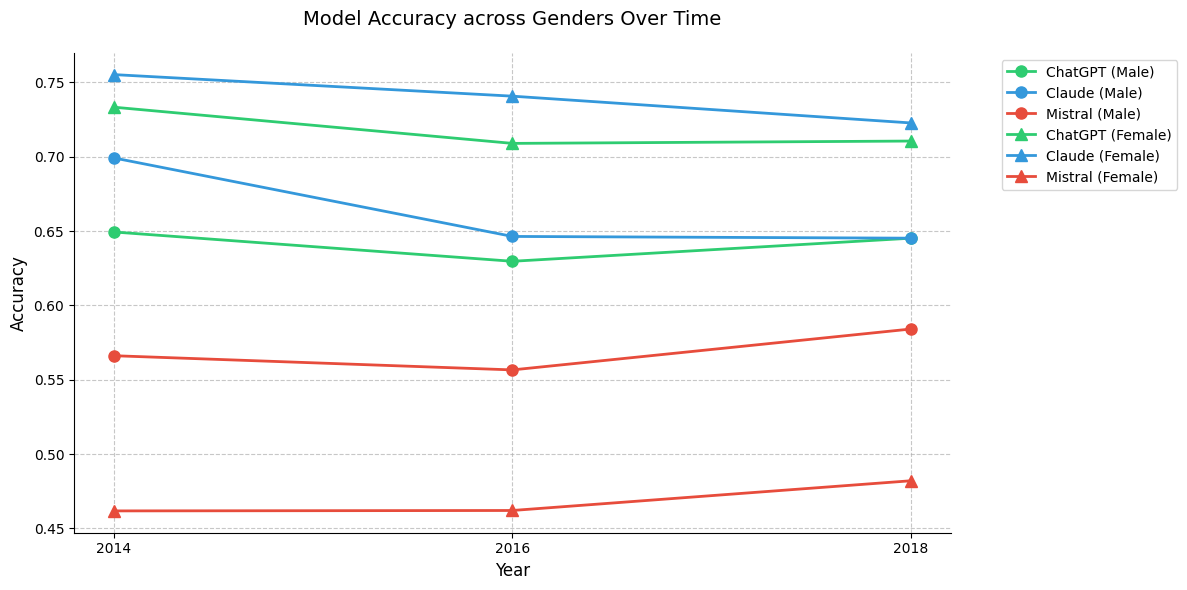

In [30]:
plt.figure(figsize=(12, 6))

years_to_show = [2014, 2016, 2018]
filtered_df = results_df[results_df['Year'].isin(years_to_show)]

colors = {
    'ChatGPT': '#2ecc71',
    'Claude': '#3498db',
    'Mistral': '#e74c3c'
}

markers = {
    'Male': 'o',
    'Female': '^'
}

accuracy_by_gender = filtered_df.groupby(['Year', 'Gender', 'Model'])['Is_Correct'].mean().unstack()


for gender in ['Male', 'Female']:
    gender_data = accuracy_by_gender.loc[(slice(None), gender), :]
    gender_data = gender_data.reset_index(level='Gender').drop('Gender', axis=1)
    
    for model in gender_data.columns:
        plt.plot(gender_data.index, gender_data[model], 
                label=f'{model} ({gender})',
                marker=markers[gender],
                color=colors[model],
                linewidth=2,
                markersize=8)

plt.title('Model Accuracy across Genders Over Time', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


plt.xticks(years_to_show)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
print("Statistical Summary of Income Predictions:")
summary_stats = results_df.groupby(['Year', 'State']).agg({
    'PINCP': ['mean', 'std', 'count'],
    'Is_Correct': 'mean'
}).round(2)
print(summary_stats)

Statistical Summary of Income Predictions:
               PINCP                 Is_Correct
                mean       std count       mean
Year State                                     
2014 CA     40182.20  57377.26  2442       0.63
     MI     33141.12  46033.62  2505       0.66
     TX     34447.15  53726.89  2355       0.64
2016 CA     48294.94  78092.04  2571       0.62
     MI     36604.06  51222.88  2544       0.64
     TX     38791.07  59357.07  2430       0.61
2018 CA     46770.68  83347.81  2526       0.63
     MI     36008.94  49798.47  2544       0.63
     TX     39066.59  56122.01  2439       0.63


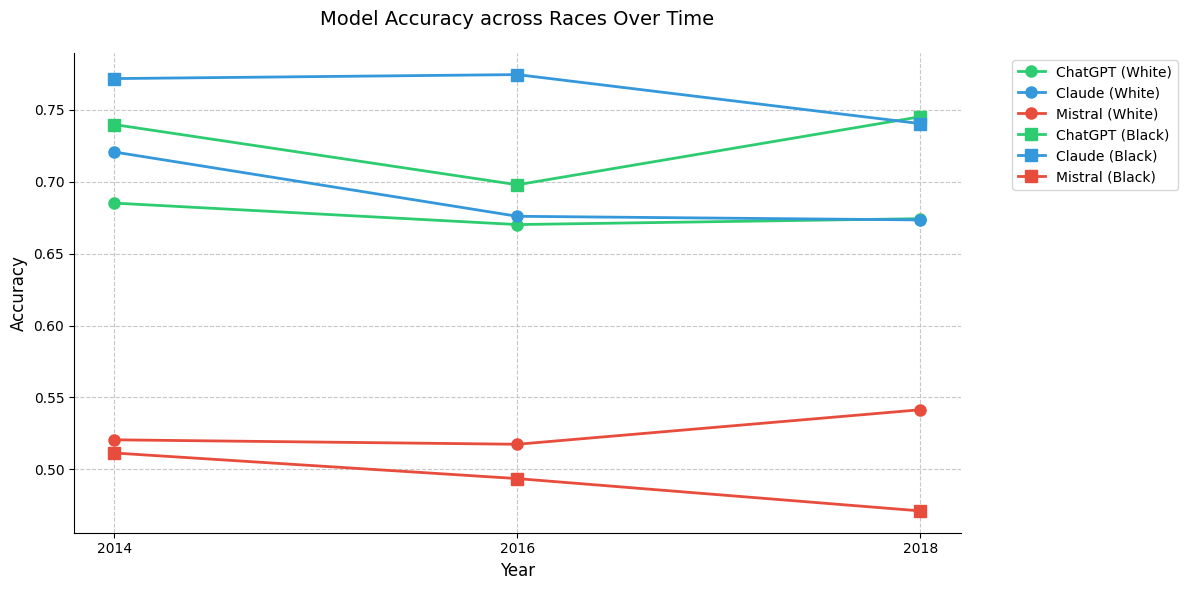

In [32]:
plt.figure(figsize=(12, 6))

race_mapping = {
    1: 'White',
    2: 'Black',
}

results_df['Race'] = results_df['RAC1P'].map(race_mapping)


years_to_show = [2014, 2016, 2018]
filtered_df = results_df[results_df['Year'].isin(years_to_show)]

accuracy_by_race = filtered_df.groupby(['Year', 'Race', 'Model'])['Is_Correct'].mean().unstack()

colors = {
    'ChatGPT': '#2ecc71',
    'Claude': '#3498db',
    'Mistral': '#e74c3c'
}

markers = ['o', 's', '^', 'D', 'v', '>']

for idx, race in enumerate(race_mapping.values()):
    race_data = accuracy_by_race.loc[(slice(None), race), :]
    if not race_data.empty:
        race_data = race_data.reset_index(level='Race').drop('Race', axis=1)
        
        for model in race_data.columns:
            plt.plot(race_data.index, race_data[model], 
                    label=f'{model} ({race})',
                    marker=markers[idx],
                    color=colors[model],
                    linewidth=2,
                    markersize=8)

plt.title('Model Accuracy across Races Over Time', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(years_to_show)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
from scipy.spatial.distance import jensenshannon

In [34]:
def calculate_distribution_shift(df, base_year=2014):

    shift_metrics = {}
    
    df = df.copy()
    df['Response_Numeric'] = (df['Response'] == 'Above').astype(int)
    
    for year in df['Year'].unique():
        if year != base_year:
            for model in df['Model'].unique():
                base_acc = df[(df['Year'] == base_year) & 
                            (df['Model'] == model)]['Response_Numeric'].mean()
                current_acc = df[(df['Year'] == year) & 
                               (df['Model'] == model)]['Response_Numeric'].mean()
                
                base_dist = df[(df['Year'] == base_year) & 
                             (df['Model'] == model)]['Response'].value_counts(normalize=True)
                current_dist = df[(df['Year'] == year) & 
                                (df['Model'] == model)]['Response'].value_counts(normalize=True)
                
                all_categories = sorted(set(base_dist.index) | set(current_dist.index))
                base_dist = base_dist.reindex(all_categories, fill_value=0)
                current_dist = current_dist.reindex(all_categories, fill_value=0)
                
                js_divergence = jensenshannon(base_dist, current_dist)
                
                shift_metrics[(model, year)] = {
                    'accuracy_shift': current_acc - base_acc,
                    'distribution_shift': js_divergence
                }
    
    return shift_metrics


In [35]:
def calculate_fairness_metrics(df):

    fairness_metrics = {}
    
    for model in df['Model'].unique():
        for year in df['Year'].unique():
            for state in df['State'].unique():
                subset = df[(df['Year'] == year) & 
                          (df['State'] == state) & 
                          (df['Model'] == model)]
                
                subset_numeric = subset.copy()
                subset_numeric['Response_Numeric'] = (subset['Response'] == 'Above').astype(int)
                subset_numeric['Actual_Numeric'] = (subset['Actual_Label'] == 'Above').astype(int)
                
                overall_positive_rate = subset_numeric['Response_Numeric'].mean()
                
                true_positive_rate = 0
                if (subset_numeric['Actual_Numeric'] == 1).sum() > 0:
                    true_positive_rate = (
                        (subset_numeric['Response_Numeric'] == 1) & 
                        (subset_numeric['Actual_Numeric'] == 1)
                    ).sum() / (subset_numeric['Actual_Numeric'] == 1).sum()
                
                false_positive_rate = 0
                if (subset_numeric['Actual_Numeric'] == 0).sum() > 0:
                    false_positive_rate = (
                        (subset_numeric['Response_Numeric'] == 1) & 
                        (subset_numeric['Actual_Numeric'] == 0)
                    ).sum() / (subset_numeric['Actual_Numeric'] == 0).sum()
                
                fairness_metrics[(model, year, state)] = {
                    'demographic_parity': overall_positive_rate,
                    'equal_opportunity': true_positive_rate,
                    'false_positive_rate': false_positive_rate
                }
    
    return fairness_metrics

In [36]:
def plot_distribution_shifts(shift_metrics):
    plt.figure(figsize=(10, 6))
    
    years = [2014, 2016, 2018]
    models = sorted(list(set(model for model, year in shift_metrics.keys())))
    
    plot_years = [year for year in years if year != min(years)]
    
    for model in models:
        shifts = []
        for year in plot_years:
            if (model, year) in shift_metrics:
                shifts.append(shift_metrics[(model, year)]['distribution_shift'])
        
        if shifts:
            plt.plot(plot_years, shifts, label=model, marker='o')
    
    plt.title('Distribution Shift Over Time')
    plt.xlabel('Year')
    plt.ylabel('Distribution Shift (JS Divergence)')
    plt.legend()
    plt.grid(True)
    
    plt.xlim(2012, 2020)
    plt.xticks([2012, 2014, 2016, 2018, 2020])
    
    plt.show()

In [37]:
def plot_fairness_trends(fairness_metrics):

    metrics = ['demographic_parity', 'equal_opportunity', 'false_positive_rate']
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    years = [2014, 2016, 2018]
    models = sorted(list(set(model for model, _, _ in fairness_metrics.keys())))
    states = sorted(list(set(state for _, _, state in fairness_metrics.keys())))
    
    for idx, metric in enumerate(metrics):
        for model in models:
            metric_values = []
            for year in years:
                year_values = [
                    fairness_metrics[(model, year, state)][metric]
                    for state in states
                    if (model, year, state) in fairness_metrics
                ]
                if year_values:
                    metric_values.append(np.mean(year_values))
            
            if metric_values:
                axes[idx].plot(years, metric_values, label=model, marker='o')
        
        axes[idx].set_title(f'{metric.replace("_", " ").title()}')
        axes[idx].set_xlabel('Year')
        axes[idx].set_ylabel('Rate')
        axes[idx].legend()
        axes[idx].grid(True)
        
        axes[idx].set_xticks(years)
    
    plt.tight_layout()
    plt.show()

In [38]:
shift_metrics = calculate_distribution_shift(results_df)
fairness_metrics = calculate_fairness_metrics(results_df)

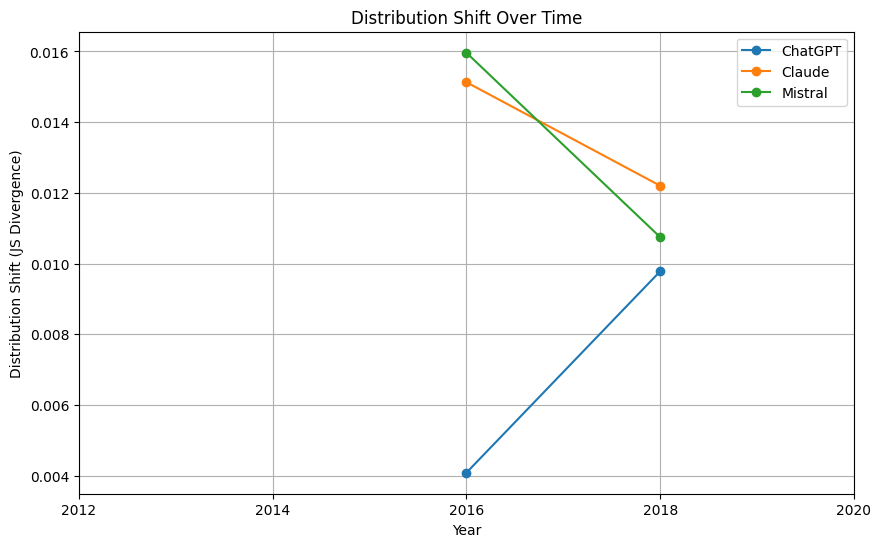

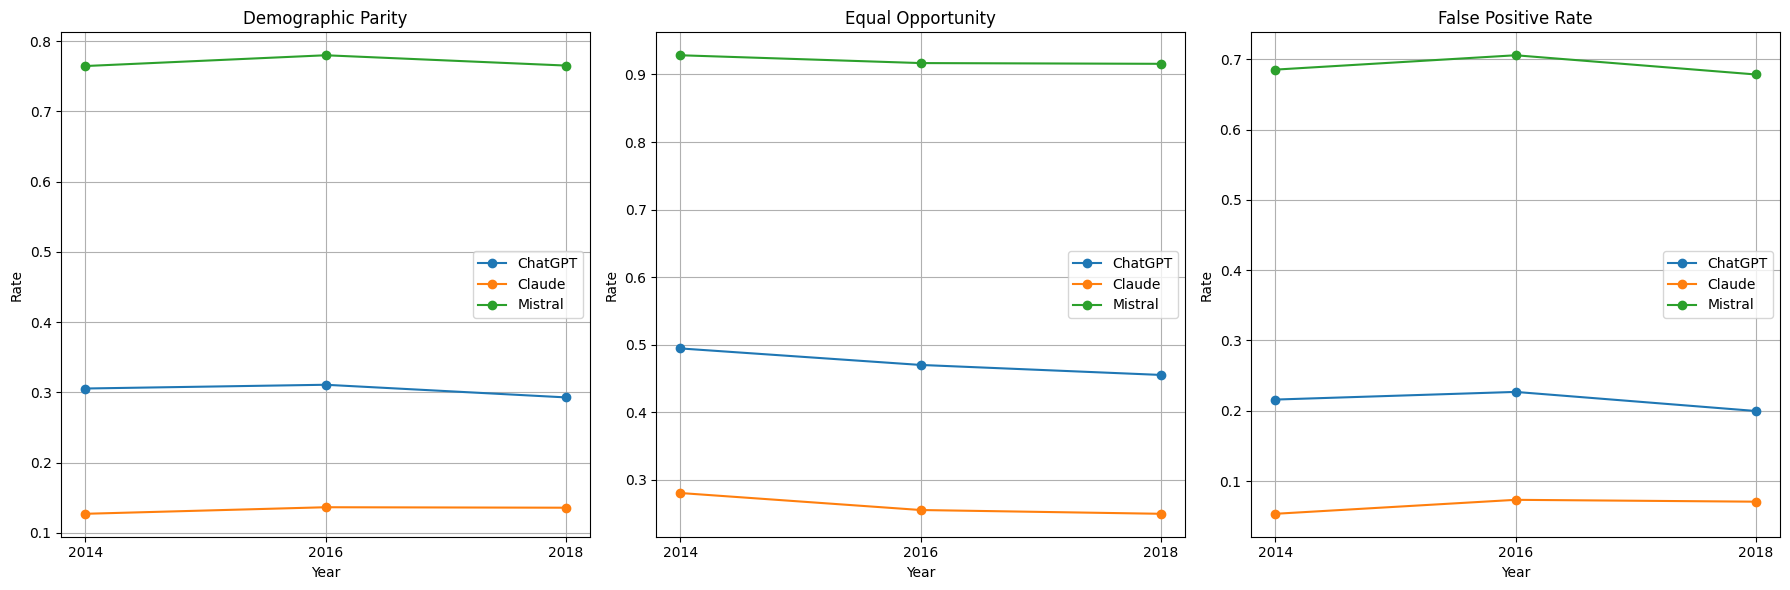

In [39]:
plot_distribution_shifts(shift_metrics)
plot_fairness_trends(fairness_metrics)

In [40]:
def print_statistical_analysis(shift_metrics, fairness_metrics):

    print("Distribution Shift Analysis:")
    for (model, year), metrics in shift_metrics.items():
        print(f"\n{model} - Year {year}:")
        print(f"Accuracy Shift: {metrics['accuracy_shift']:.3f}")
        print(f"Distribution Shift: {metrics['distribution_shift']:.3f}")
    
    print("\nFairness Metrics Summary:")
    for (model, year, state), metrics in fairness_metrics.items():
        print(f"\n{model} - Year {year} - State {state}:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.3f}")

print_statistical_analysis(shift_metrics, fairness_metrics)

Distribution Shift Analysis:

ChatGPT - Year 2016:
Accuracy Shift: 0.005
Distribution Shift: 0.004

Claude - Year 2016:
Accuracy Shift: 0.009
Distribution Shift: 0.015

Mistral - Year 2016:
Accuracy Shift: 0.015
Distribution Shift: 0.016

ChatGPT - Year 2018:
Accuracy Shift: -0.013
Distribution Shift: 0.010

Claude - Year 2018:
Accuracy Shift: 0.009
Distribution Shift: 0.012

Mistral - Year 2018:
Accuracy Shift: 0.001
Distribution Shift: 0.011

Fairness Metrics Summary:

ChatGPT - Year 2014 - State CA:
demographic_parity: 0.320
equal_opportunity: 0.460
false_positive_rate: 0.233

ChatGPT - Year 2014 - State TX:
demographic_parity: 0.322
equal_opportunity: 0.524
false_positive_rate: 0.228

ChatGPT - Year 2014 - State MI:
demographic_parity: 0.275
equal_opportunity: 0.500
false_positive_rate: 0.188

ChatGPT - Year 2016 - State CA:
demographic_parity: 0.313
equal_opportunity: 0.446
false_positive_rate: 0.226

ChatGPT - Year 2016 - State TX:
demographic_parity: 0.328
equal_opportunity: 0.4

In [41]:
def plot_gender_predictions():
    plt.figure(figsize=(15, 5))
    
    for idx, year in enumerate([2014, 2016, 2018]):
        plt.subplot(1, 3, idx+1)
        
        gender_rates = []
        for model in results_df['Model'].unique():
            year_data = results_df[results_df['Year'] == year]
            model_data = year_data[year_data['Model'] == model]
            
            male_rate = (model_data[model_data['Gender'] == 'Male']['Response'] == 'Above').mean()
            female_rate = (model_data[model_data['Gender'] == 'Female']['Response'] == 'Above').mean()
            
            gender_rates.append({
                'Model': model,
                'Male': male_rate,
                'Female': female_rate
            })
        
        df_plot = pd.DataFrame(gender_rates)
        x = np.arange(len(df_plot))
        width = 0.35
        
        plt.bar(x - width/2, df_plot['Male'], width, label='Male')
        plt.bar(x + width/2, df_plot['Female'], width, label='Female')
        
        plt.title(f'Gender Prediction Rates - {year}')
        plt.xlabel('Model')
        plt.ylabel('Rate of "Above" Predictions')
        plt.xticks(x, df_plot['Model'])
        plt.legend()
    
    plt.tight_layout()
    plt.show()

In [42]:
def plot_demographic_predictions():
    race_mapping = {
        1: 'White',
        2: 'Black',
        3: 'American Indian',
        4: 'Alaska Native',
        5: 'American Indian and Alaska Native',
        6: 'Asian',
        7: 'Native Hawaiian and Pacific Islander',
        8: 'Other',
        9: 'Multiple Races'
    }
    
    plt.figure(figsize=(15, 12))
    
    for idx, model in enumerate(results_df['Model'].unique()):
        plt.subplot(3, 1, idx+1)
        
        race_rates = []
        for year in [2014, 2016, 2018]:
            year_data = results_df[results_df['Year'] == year]
            model_data = year_data[year_data['Model'] == model]
            
            for race_code in model_data['RAC1P'].unique():
                rate = (model_data[model_data['RAC1P'] == race_code]['Response'] == 'Above').mean()
                race_rates.append({
                    'Year': year,
                    'Race': race_mapping.get(race_code, f'Race {race_code}'),
                    'Rate': rate
                })
        
        df_plot = pd.DataFrame(race_rates)
        
        colors = plt.cm.Set2(np.linspace(0, 1, len(df_plot['Race'].unique())))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']
        
        for (race, color, marker) in zip(df_plot['Race'].unique(), colors, markers):
            race_data = df_plot[df_plot['Race'] == race]
            plt.plot(race_data['Year'], race_data['Rate'], 
                    marker=marker, label=race, color=color, 
                    linewidth=2, markersize=8)
        
        plt.title(f'Demographic Prediction Rates - {model}')
        plt.xlabel('Year')
        plt.ylabel('Rate of "Above" Predictions')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.ylim(0, 1)  # Set y-axis from 0 to 1
    
    plt.tight_layout()
    plt.show()

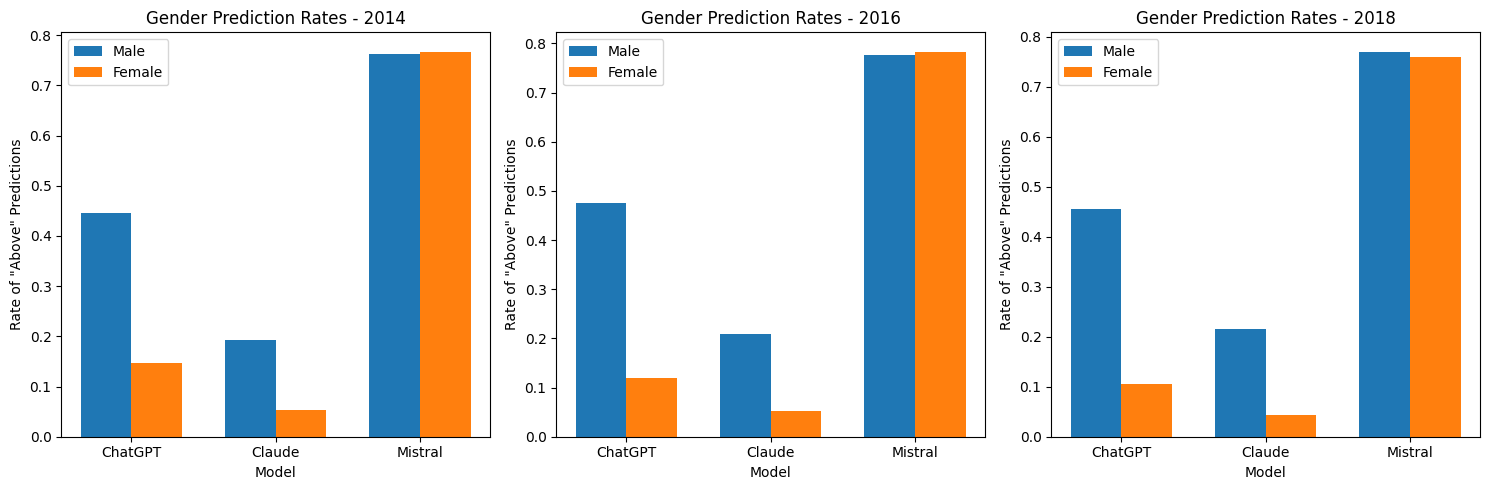

In [43]:
plot_gender_predictions()

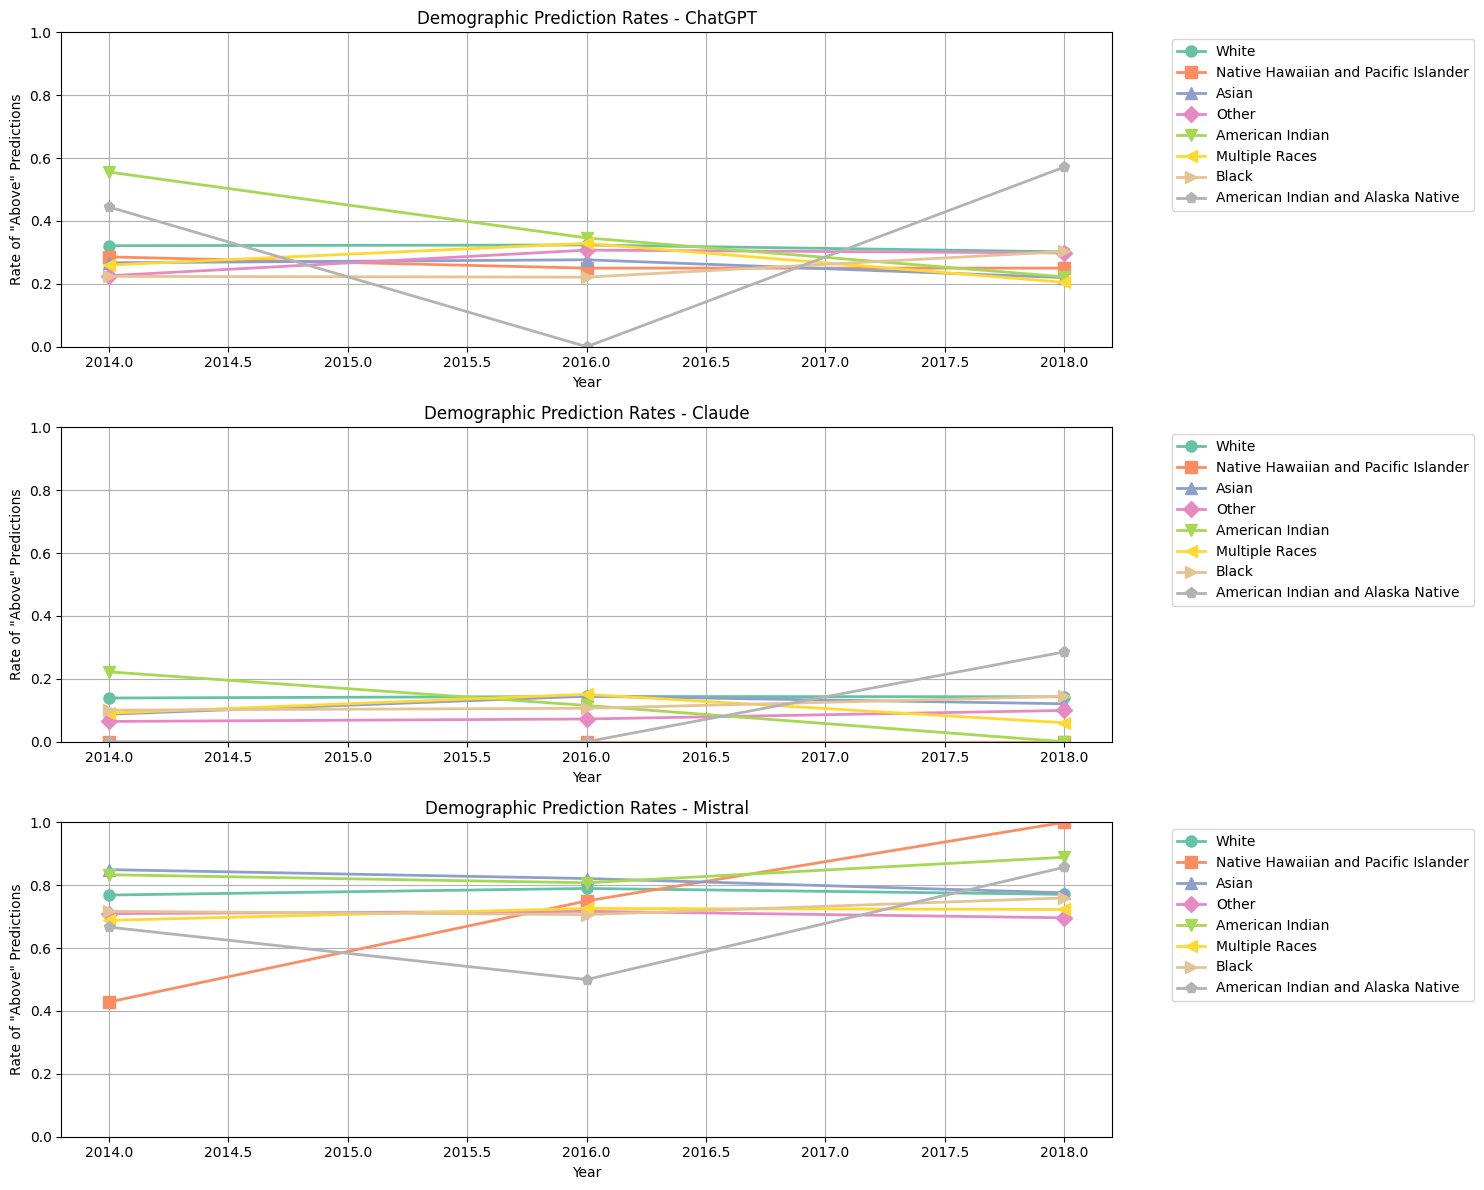

In [44]:
plot_demographic_predictions()

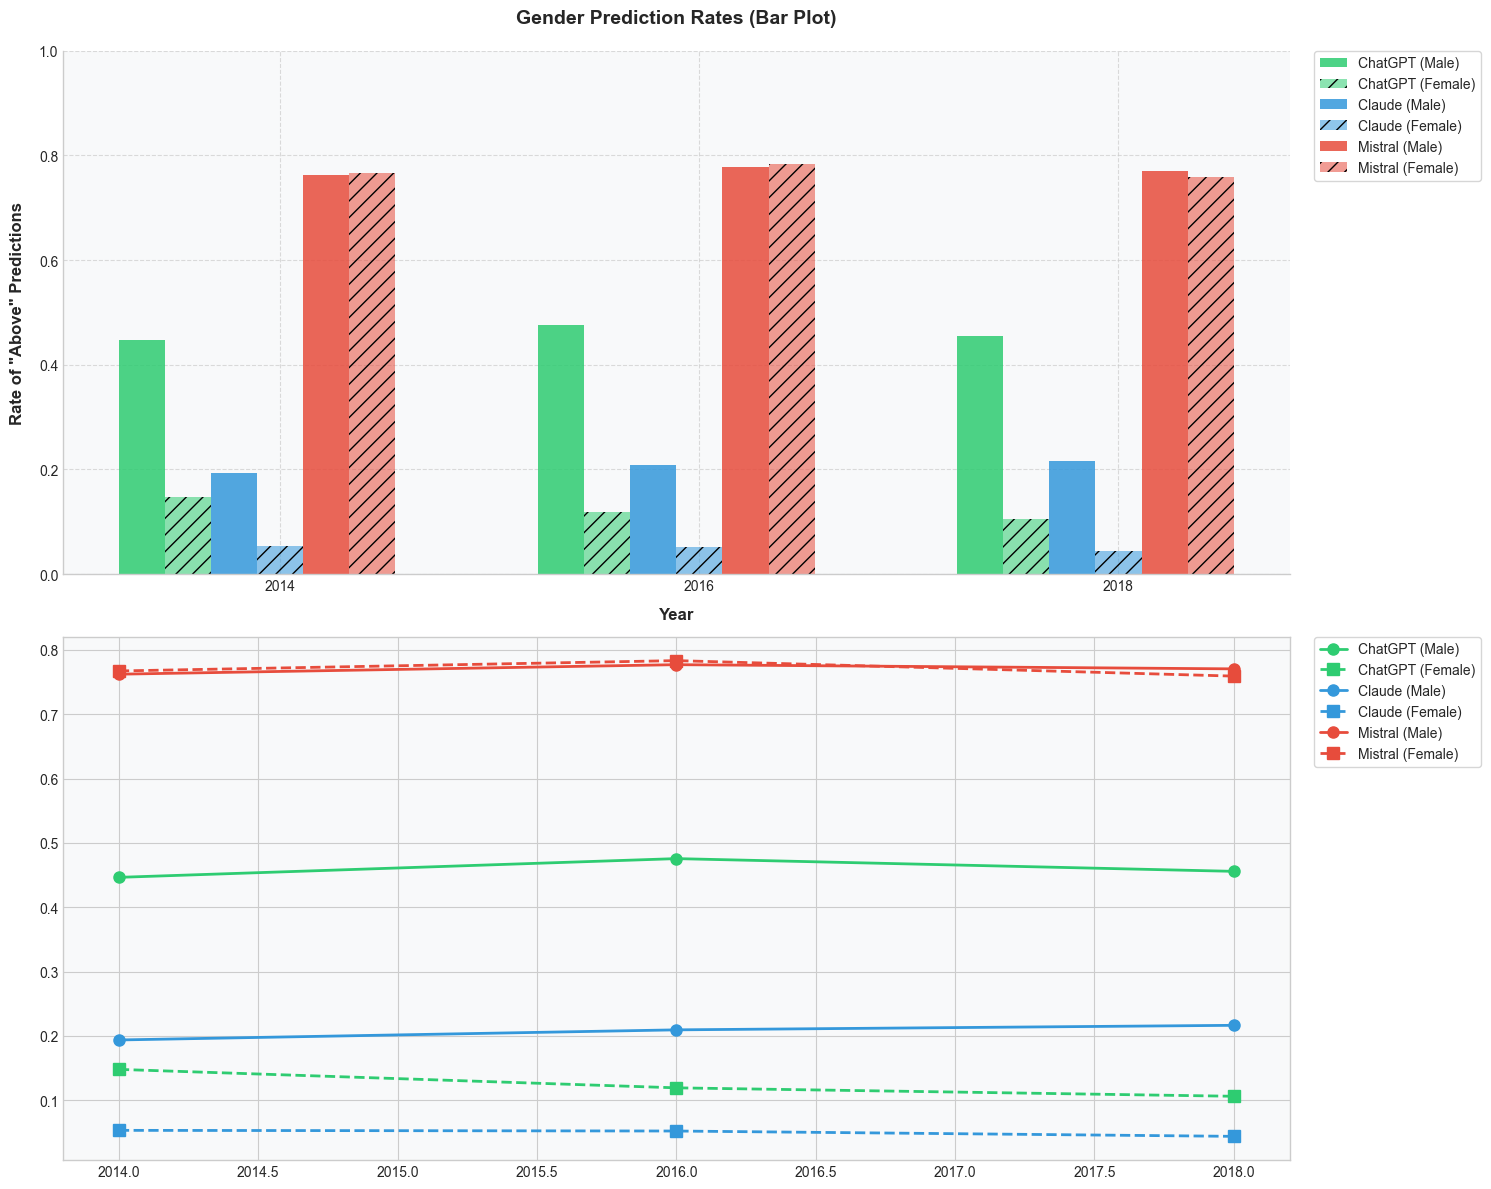

In [45]:
def plot_gender_predictions_dual():
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[1, 1])
    
    gender_rates = []
    for year in [2014, 2016, 2018]:
        for model in results_df['Model'].unique():
            year_data = results_df[results_df['Year'] == year]
            model_data = year_data[year_data['Model'] == model]
            
            male_rate = (model_data[model_data['Gender'] == 'Male']['Response'] == 'Above').mean()
            female_rate = (model_data[model_data['Gender'] == 'Female']['Response'] == 'Above').mean()
            
            gender_rates.append({
                'Year': year,
                'Model': model,
                'Male': male_rate,
                'Female': female_rate
            })
    
    df_plot = pd.DataFrame(gender_rates)
    
    colors = {
        'ChatGPT': '#2ecc71',
        'Claude': '#3498db',
        'Mistral': '#e74c3c'
    }
    
    x = np.arange(len(df_plot['Year'].unique()))
    width = 0.11
    
    positions = {
        'ChatGPT_Male': -3,
        'ChatGPT_Female': -2,
        'Claude_Male': -1,
        'Claude_Female': 0,
        'Mistral_Male': 1,
        'Mistral_Female': 2
    }
    
    for model in df_plot['Model'].unique():
        model_data = df_plot[df_plot['Model'] == model]
        
        ax1.bar(x + positions[f'{model}_Male']*width, model_data['Male'], 
                width, label=f'{model} (Male)',
                color=colors[model], alpha=0.85)
        
        ax1.bar(x + positions[f'{model}_Female']*width, model_data['Female'], 
                width, label=f'{model} (Female)',
                color=colors[model], alpha=0.55,
                hatch='//')
    
    ax1.set_xlabel('Year', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Rate of "Above" Predictions', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_title('Gender Prediction Rates (Bar Plot)', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels([2014, 2016, 2018])
    ax1.set_ylim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    for model in df_plot['Model'].unique():
        model_data = df_plot[df_plot['Model'] == model]
        
        ax2.plot(model_data['Year'], model_data['Male'], 
                marker='o', label=f'{model} (Male)',
                color=colors[model], linewidth=2, markersize=8)
        
        ax2.plot(model_data['Year'], model_data['Female'], 
                marker='s', label=f'{model} (Female)',
                color=colors[model], linewidth=2, 
                linestyle='--', markersize=8)
    
    for ax in [ax1, ax2]:
        ax.set_facecolor('#f8f9fa')
        ax.legend(bbox_to_anchor=(1.02, 1), 
                 loc='upper left', 
                 borderaxespad=0,
                 frameon=True,
                 fontsize=10)
    
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

plot_gender_predictions_dual()

In [49]:
results_df['Is_Correct']

0         True
1         True
2        False
3         True
4         True
         ...  
26995    False
26996     True
26997     True
26998     True
26999     True
Name: Is_Correct, Length: 27000, dtype: bool

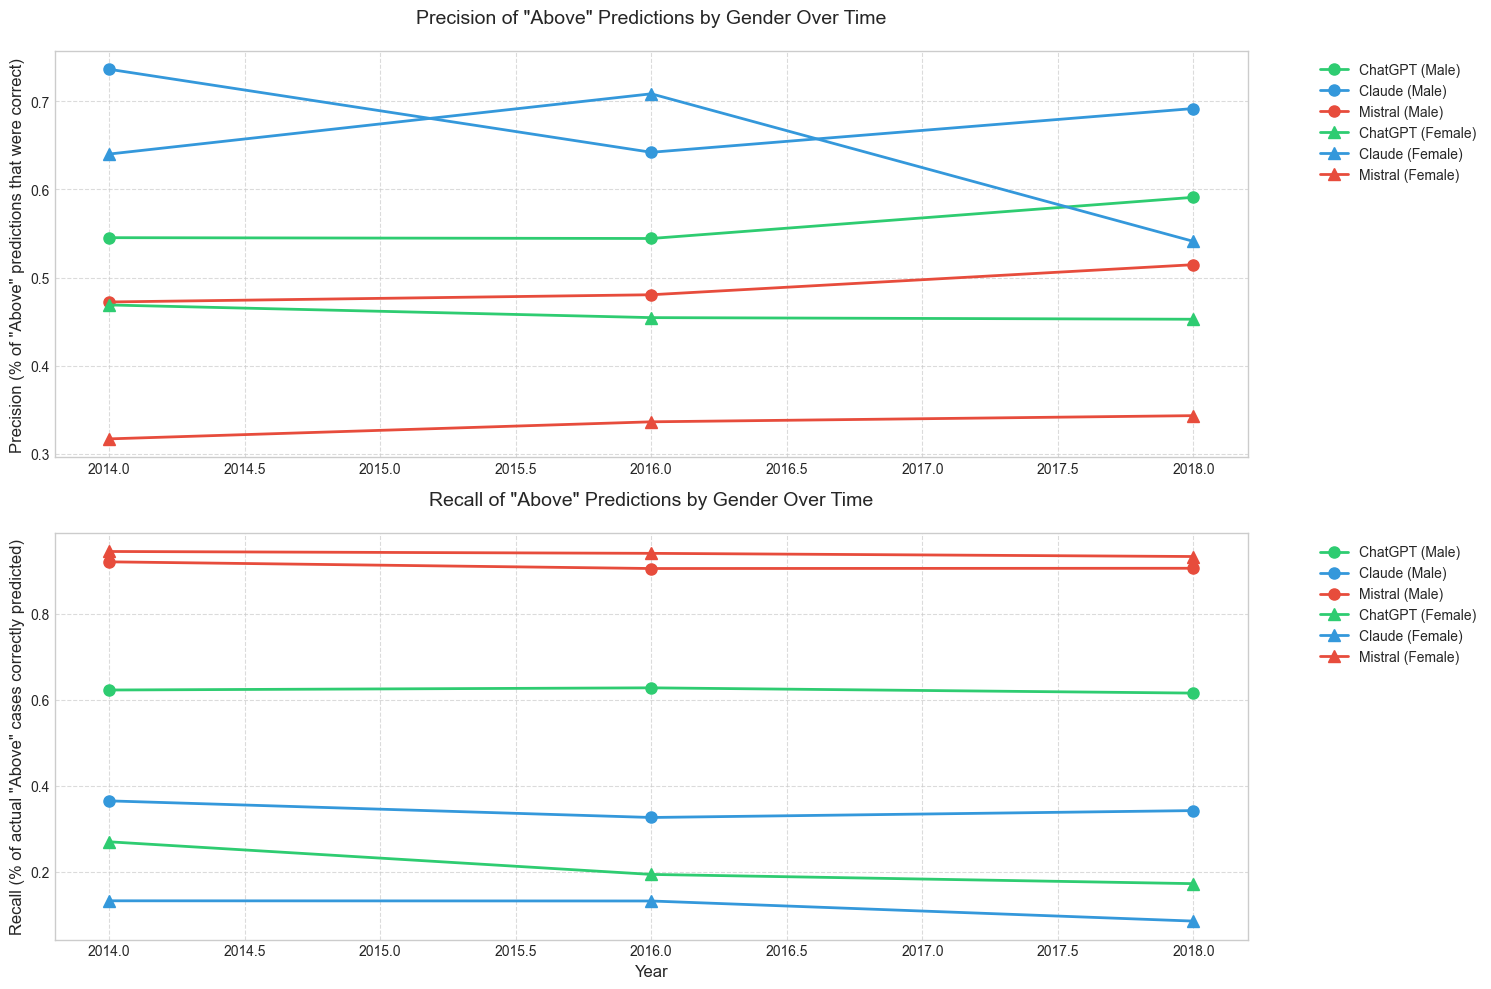

In [50]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)

above_precision = results_df[results_df['Response'] == 'Above'].groupby(
    ['Year', 'Gender', 'Model'])['Is_Correct'].mean().unstack()

above_recall = results_df[results_df['Actual_Label'] == 'Above'].groupby(
    ['Year', 'Gender', 'Model'])['Is_Correct'].mean().unstack()

colors = {
    'ChatGPT': '#2ecc71',
    'Claude': '#3498db',
    'Mistral': '#e74c3c'
}

markers = {
    'Male': 'o',
    'Female': '^'
}

for gender in ['Male', 'Female']:
    gender_data = above_precision.loc[(slice(None), gender), :]
    gender_data = gender_data.reset_index(level='Gender').drop('Gender', axis=1)
    
    for model in gender_data.columns:
        plt.plot(gender_data.index, gender_data[model], 
                label=f'{model} ({gender})',
                marker=markers[gender],
                color=colors[model],
                linewidth=2,
                markersize=8)

plt.title('Precision of "Above" Predictions by Gender Over Time', fontsize=14, pad=20)
plt.ylabel('Precision (% of "Above" predictions that were correct)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.subplot(2, 1, 2)
for gender in ['Male', 'Female']:
    gender_data = above_recall.loc[(slice(None), gender), :]
    gender_data = gender_data.reset_index(level='Gender').drop('Gender', axis=1)
    
    for model in gender_data.columns:
        plt.plot(gender_data.index, gender_data[model], 
                label=f'{model} ({gender})',
                marker=markers[gender],
                color=colors[model],
                linewidth=2,
                markersize=8)

plt.title('Recall of "Above" Predictions by Gender Over Time', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Recall (% of actual "Above" cases correctly predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

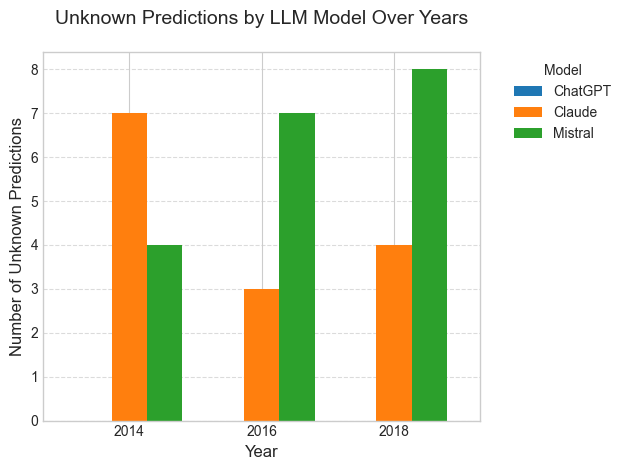

In [46]:
plt.figure(figsize=(12, 6))

unknown_predictions = results_df.groupby(['Year', 'Model'])['Response'].apply(
    lambda x: (x == 'Unknown').sum()
).unstack()

unknown_predictions.plot(kind='bar', width=0.8)

plt.title('Unknown Predictions by LLM Model Over Years', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Unknown Predictions', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

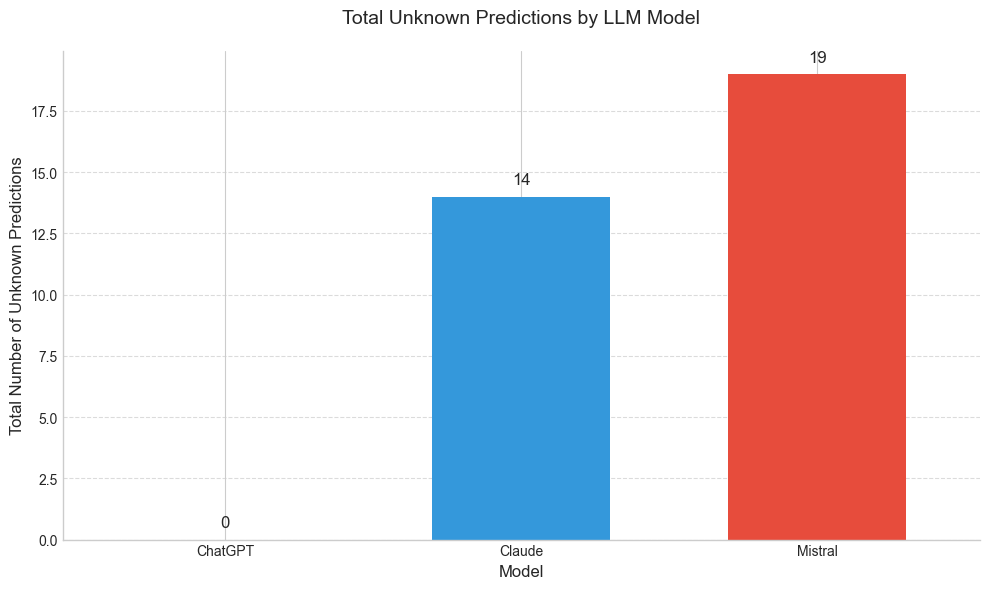

In [47]:
plt.figure(figsize=(10, 6))

unknown_counts = results_df.groupby('Model')['Response'].apply(
    lambda x: (x == 'Unknown').sum()
)

colors = {'ChatGPT': '#2ecc71', 'Claude': '#3498db', 'Mistral': '#e74c3c'}
unknown_counts.plot(kind='bar', color=[colors[model] for model in unknown_counts.index], width=0.6)

plt.title('Total Unknown Predictions by LLM Model', fontsize=14, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Total Number of Unknown Predictions', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(unknown_counts):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12)

plt.xticks(rotation=0)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\bsudh\AppData\Local\Temp\ipykernel_1468\136691806.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'Demographic Parity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_demographic_parity),
C:\Users\bsudh\AppData\Local\Temp\ipykernel_1468\136691806.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'Equal Opportunity': results_df.groupby(['Year', 'Demographic', 'Model']).

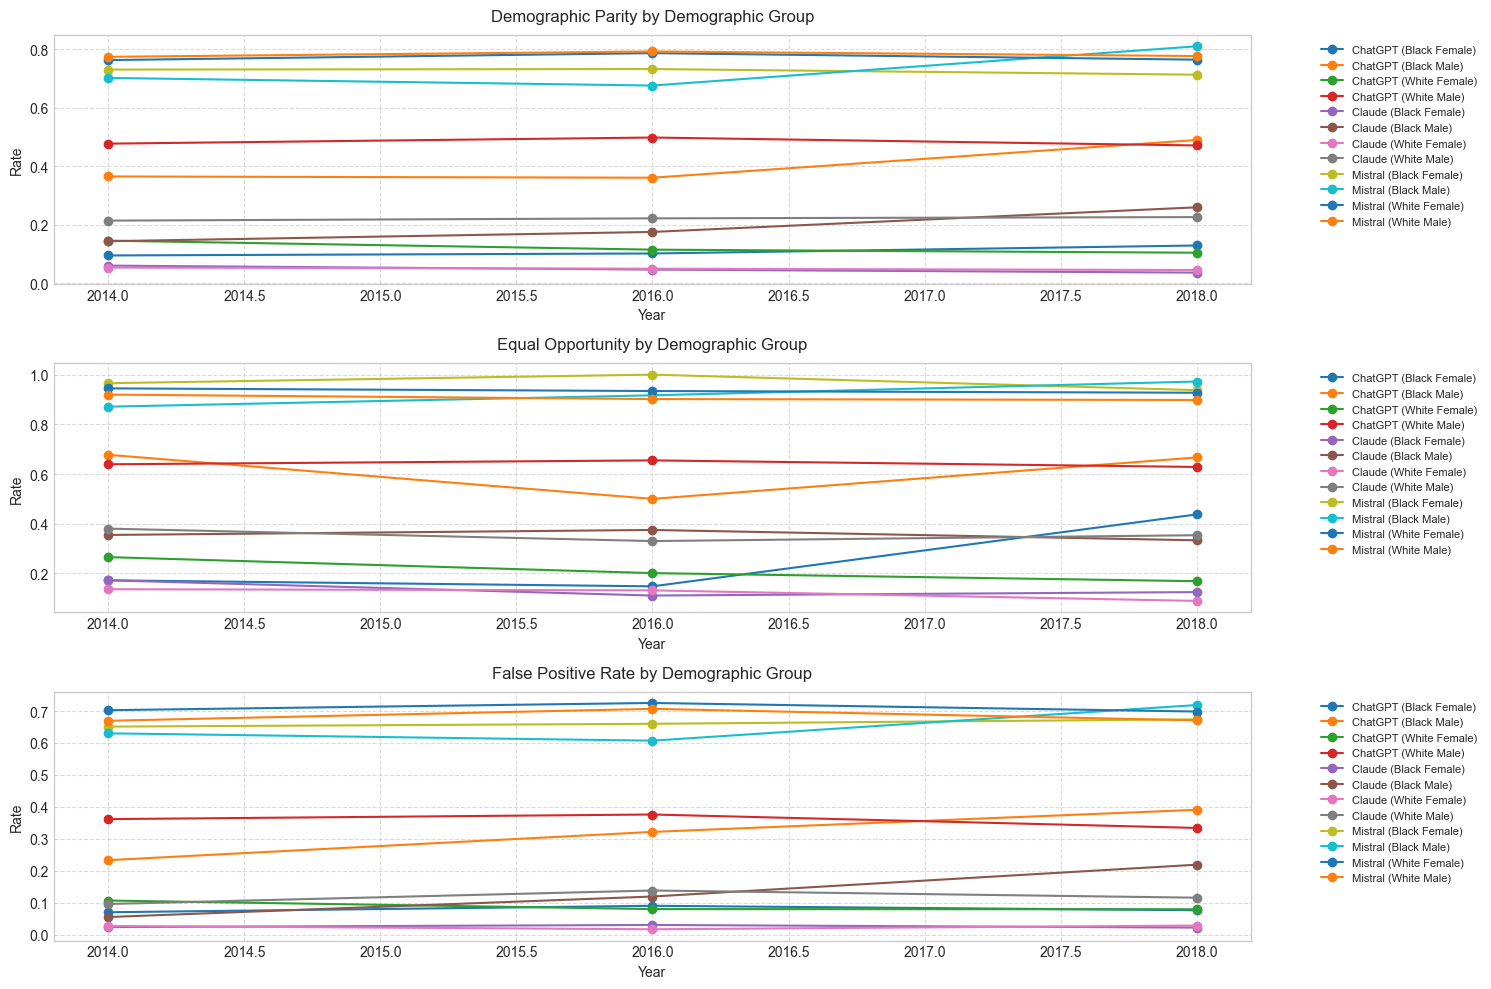


Summary Statistics:

Demographic Parity:
Model    Demographic 
ChatGPT  Black Female    0.109
         Black Male      0.405
         White Female    0.122
         White Male      0.482
Claude   Black Female    0.048
         Black Male      0.193
         White Female    0.050
         White Male      0.221
Mistral  Black Female    0.725
         Black Male      0.729
         White Female    0.771
         White Male      0.781
dtype: float64

Equal Opportunity:
Model    Demographic 
ChatGPT  Black Female    0.253
         Black Male      0.615
         White Female    0.212
         White Male      0.641
Claude   Black Female    0.136
         Black Male      0.354
         White Female    0.119
         White Male      0.355
Mistral  Black Female    0.968
         Black Male      0.920
         White Female    0.935
         White Male      0.906
dtype: float64

False Positive Rate:
Model    Demographic 
ChatGPT  Black Female    0.079
         Black Male      0.315
         White

In [52]:
def plot_intersectional_metrics(results_df):
    plt.figure(figsize=(15, 10))
    
    results_df['Demographic'] = results_df['Race'] + ' ' + results_df['Gender']
    
    def calculate_demographic_parity(group):
        return (group['Response'] == 'Above').mean()
    
    def calculate_equal_opportunity(group):
        above_cases = group[group['Actual_Label'] == 'Above']
        return above_cases['Is_Correct'].mean() if len(above_cases) > 0 else 0
    
    def calculate_false_positive(group):
        below_cases = group[group['Actual_Label'] == 'Below']
        return (below_cases['Response'] == 'Above').mean() if len(below_cases) > 0 else 0
    
    metrics = {
        'Demographic Parity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_demographic_parity),
        'Equal Opportunity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_equal_opportunity),
        'False Positive Rate': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_false_positive)
    }
    
    for idx, (metric_name, metric_data) in enumerate(metrics.items(), 1):
        plt.subplot(3, 1, idx)
        
        metric_df = metric_data.reset_index()
        
        for model in results_df['Model'].unique():
            model_data = metric_df[metric_df['Model'] == model]
            
            for demo in model_data['Demographic'].unique():
                demo_data = model_data[model_data['Demographic'] == demo]
                plt.plot(demo_data['Year'], demo_data[0], 
                        label=f'{model} ({demo})',
                        marker='o')
        
        plt.title(f'{metric_name} by Demographic Group', fontsize=12, pad=10)
        plt.xlabel('Year', fontsize=10)
        plt.ylabel('Rate', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

    print("\nSummary Statistics:")
    for metric_name, metric_data in metrics.items():
        print(f"\n{metric_name}:")
        print(metric_data.groupby(['Model', 'Demographic']).mean().round(3))
plot_intersectional_metrics(results_df)

In [56]:
def plot_intersectional_metrics_race(results_df):
    plt.figure(figsize=(15, 10))
    
    results_df = results_df[results_df['Race'].isin(['White', 'Black'])]
    
    results_df['Demographic'] = results_df['Race']
    
    def calculate_demographic_parity(group):
        return (group['Response'] == 'Above').mean()
    
    def calculate_equal_opportunity(group):
        above_cases = group[group['Actual_Label'] == 'Above']
        return above_cases['Is_Correct'].mean() if len(above_cases) > 0 else 0
    
    def calculate_false_positive(group):
        below_cases = group[group['Actual_Label'] == 'Below']
        return (below_cases['Response'] == 'Above').mean() if len(below_cases) > 0 else 0
    
    metrics = {
        'Demographic Parity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_demographic_parity),
        'Equal Opportunity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_equal_opportunity),
        'False Positive Rate': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_false_positive)
    }
    
    # Plot metrics
    colors = {
        'ChatGPT': '#2ecc71',
        'Claude': '#3498db',
        'Mistral': '#e74c3c'
    }
    
    markers = {
        'White': 'o',
        'Black': '^'
    }
    
    for idx, (metric_name, metric_data) in enumerate(metrics.items(), 1):
        plt.subplot(3, 1, idx)
        
        metric_df = metric_data.reset_index()
        
        for model in results_df['Model'].unique():
            model_data = metric_df[metric_df['Model'] == model]
            
            for demo in ['White', 'Black']:
                demo_data = model_data[model_data['Demographic'] == demo]
                plt.plot(demo_data['Year'], demo_data[0], 
                        label=f'{model} ({demo})',
                        marker=markers[demo],
                        color=colors[model],
                        linewidth=2,
                        markersize=8)
        
        plt.title(f'{metric_name} by Race', fontsize=12, pad=10)
        plt.xlabel('Year', fontsize=10)
        plt.ylabel('Rate', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

    print("\nSummary Statistics:")
    for metric_name, metric_data in metrics.items():
        print(f"\n{metric_name}:")
        print(metric_data.groupby(['Model', 'Demographic']).mean().round(3))

C:\Users\bsudh\AppData\Local\Temp\ipykernel_1468\1547086949.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['Demographic'] = results_df['Race']
C:\Users\bsudh\AppData\Local\Temp\ipykernel_1468\1547086949.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'Demographic Parity': results_df.groupby(['Year', 'Demographic', 'Model']).apply(calculate_demographic_parity),
C:\Users\bsudh\AppData\Local\Temp\ipykernel_1468\1547086949.py:24: Deprecatio

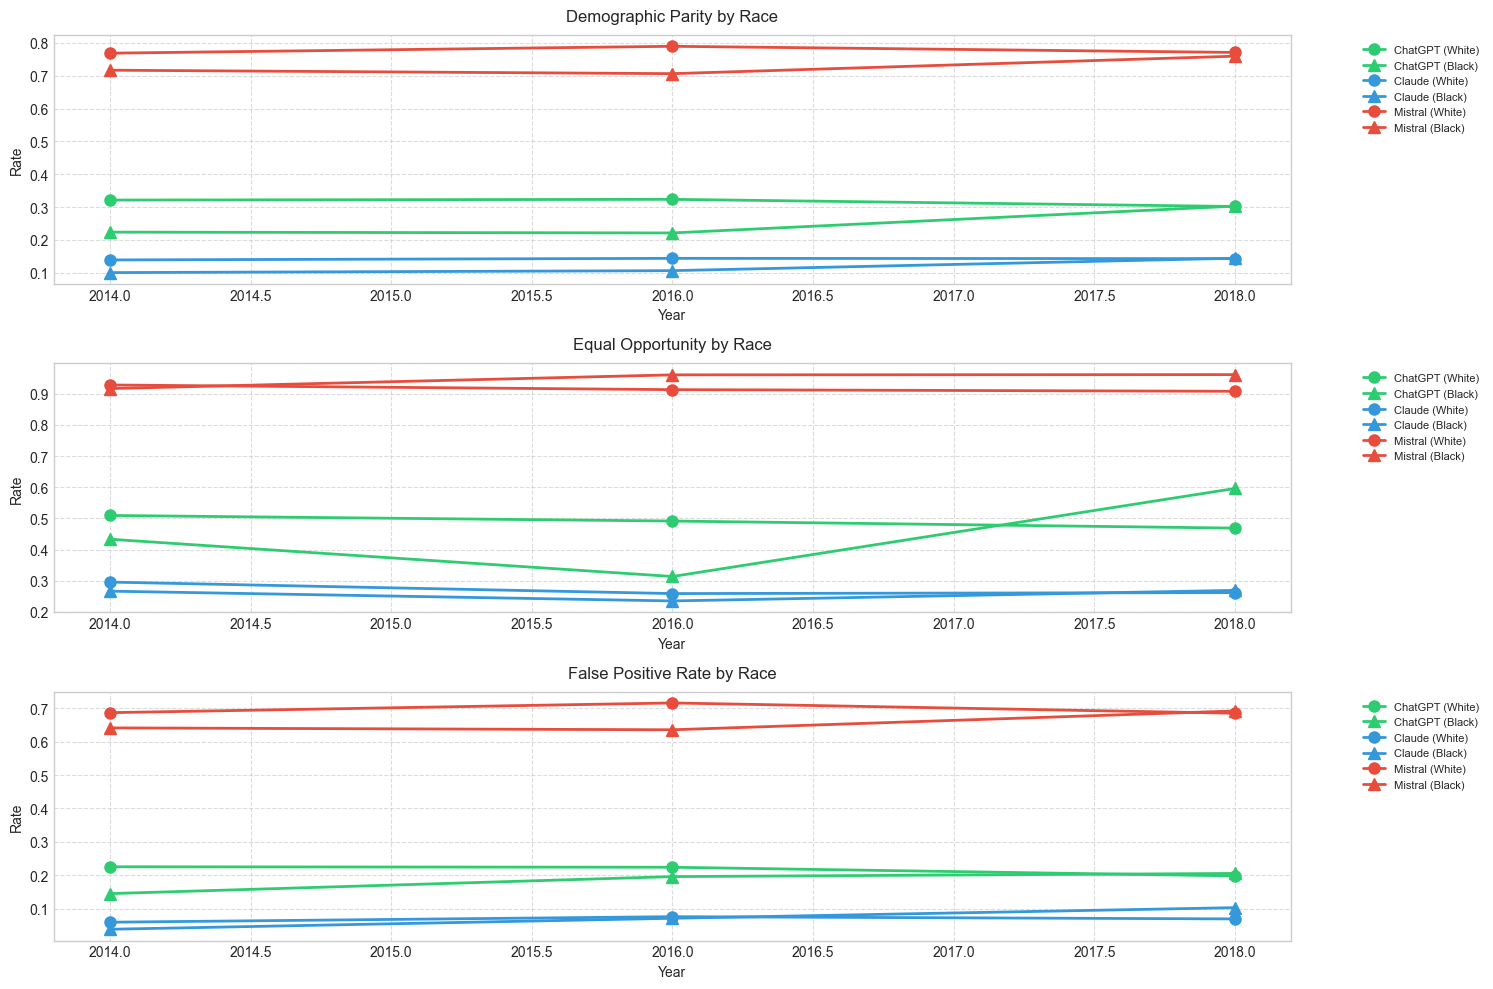


Summary Statistics:

Demographic Parity:
Model    Demographic
ChatGPT  Black          0.249
         White          0.316
Claude   Black          0.117
         White          0.142
Mistral  Black          0.728
         White          0.776
dtype: float64

Equal Opportunity:
Model    Demographic
ChatGPT  Black          0.448
         White          0.490
Claude   Black          0.257
         White          0.272
Mistral  Black          0.946
         White          0.917
dtype: float64

False Positive Rate:
Model    Demographic
ChatGPT  Black          0.182
         White          0.216
Claude   Black          0.070
         White          0.068
Mistral  Black          0.657
         White          0.696
dtype: float64


In [57]:
plot_intersectional_metrics_race(results_df)

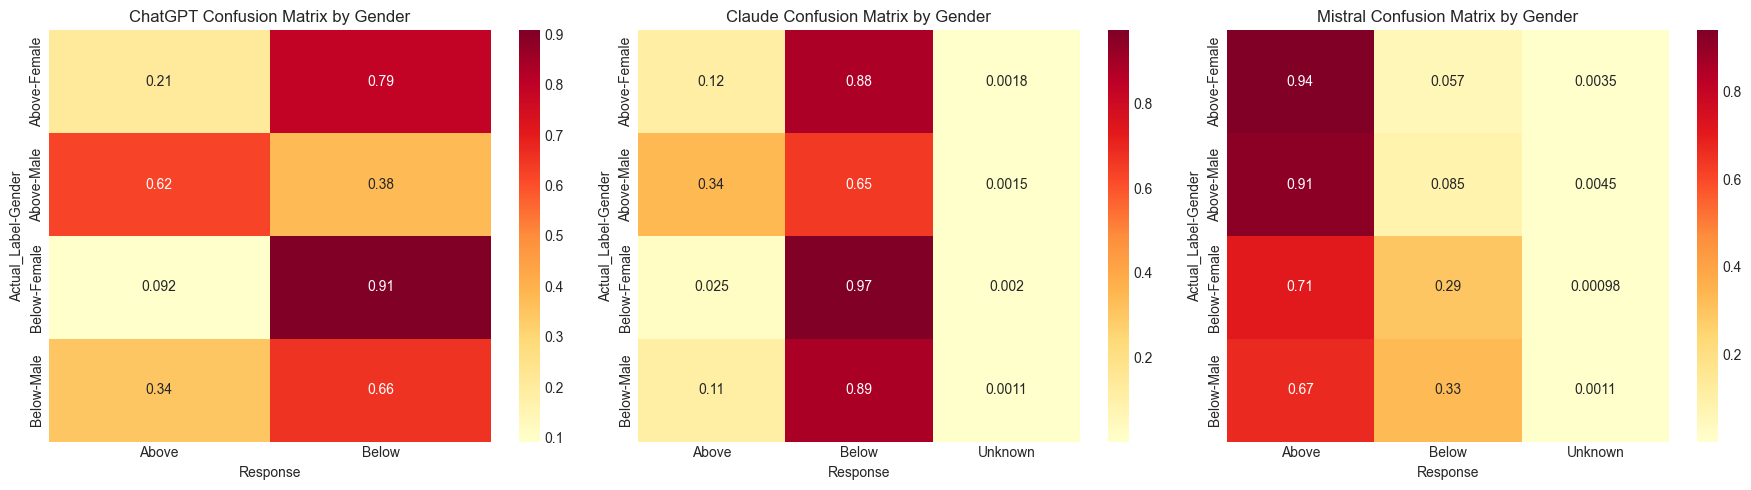

In [58]:
def plot_confusion_matrices(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, model in enumerate(results_df['Model'].unique()):
        model_data = results_df[results_df['Model'] == model]
        
        conf_matrix = pd.crosstab(
            [model_data['Actual_Label'], model_data['Gender']], 
            model_data['Response'],
            normalize='index'
        )
        
        sns.heatmap(conf_matrix, annot=True, cmap='YlOrRd', ax=axes[idx])
        axes[idx].set_title(f'{model} Confusion Matrix by Gender')
    
    plt.tight_layout()
    plt.show()
plot_confusion_matrices(results_df)

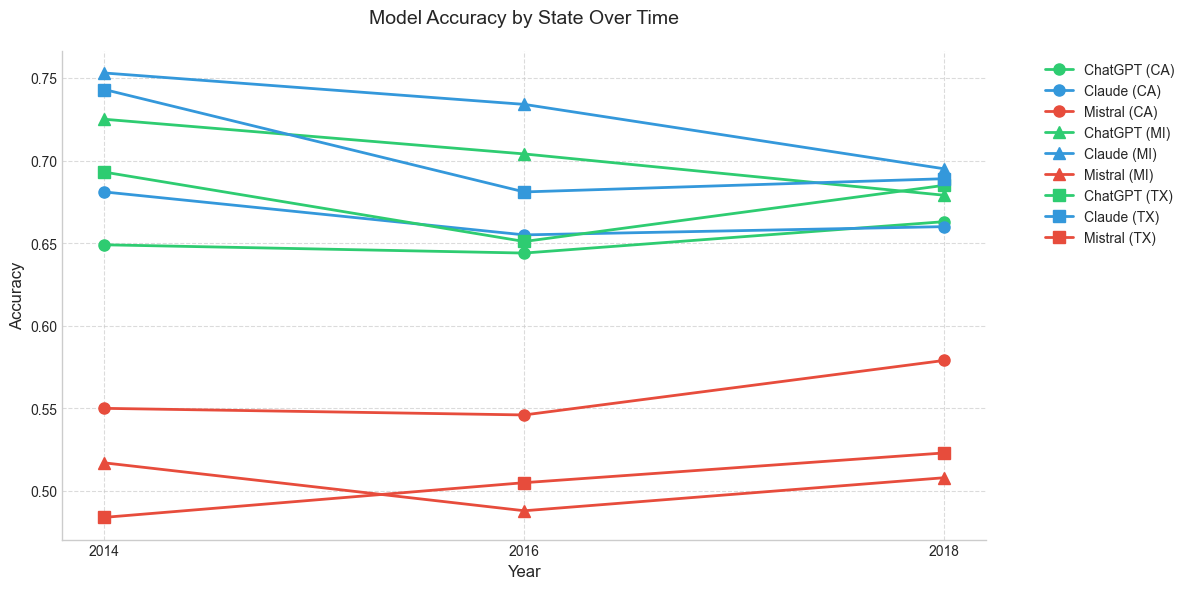


Accuracy values by state, year, and model:

CA:
Model  ChatGPT  Claude  Mistral
Year                           
2014     0.649   0.681    0.550
2016     0.644   0.655    0.546
2018     0.663   0.660    0.579

MI:
Model  ChatGPT  Claude  Mistral
Year                           
2014     0.725   0.753    0.517
2016     0.704   0.734    0.488
2018     0.679   0.695    0.508

TX:
Model  ChatGPT  Claude  Mistral
Year                           
2014     0.693   0.743    0.484
2016     0.651   0.681    0.505
2018     0.685   0.689    0.523


In [62]:
plt.figure(figsize=(12, 6))

states_to_show = ['CA', 'MI', 'TX']
filtered_df = results_df[results_df['State'].isin(states_to_show)]

accuracy_by_state_year = filtered_df.groupby(['Year', 'State', 'Model'])['Is_Correct'].mean().unstack()

colors = {
    'ChatGPT': '#2ecc71',
    'Claude': '#3498db',
    'Mistral': '#e74c3c'
}

markers = {
    'CA': 'o',
    'MI': '^',
    'TX': 's'
}

for state in states_to_show:
    state_data = filtered_df[filtered_df['State'] == state]
    state_accuracy = state_data.groupby(['Year', 'Model'])['Is_Correct'].mean().unstack()
    
    for model in state_accuracy.columns:
        plt.plot(state_accuracy.index, state_accuracy[model], 
                label=f'{model} ({state})',
                marker=markers[state],
                color=colors[model],
                linewidth=2,
                markersize=8)

plt.title('Model Accuracy by State Over Time', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks([2014, 2016, 2018])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nAccuracy values by state, year, and model:")
for state in states_to_show:
    print(f"\n{state}:")
    state_data = filtered_df[filtered_df['State'] == state]
    print(state_data.groupby(['Year', 'Model'])['Is_Correct'].mean().unstack().round(3))

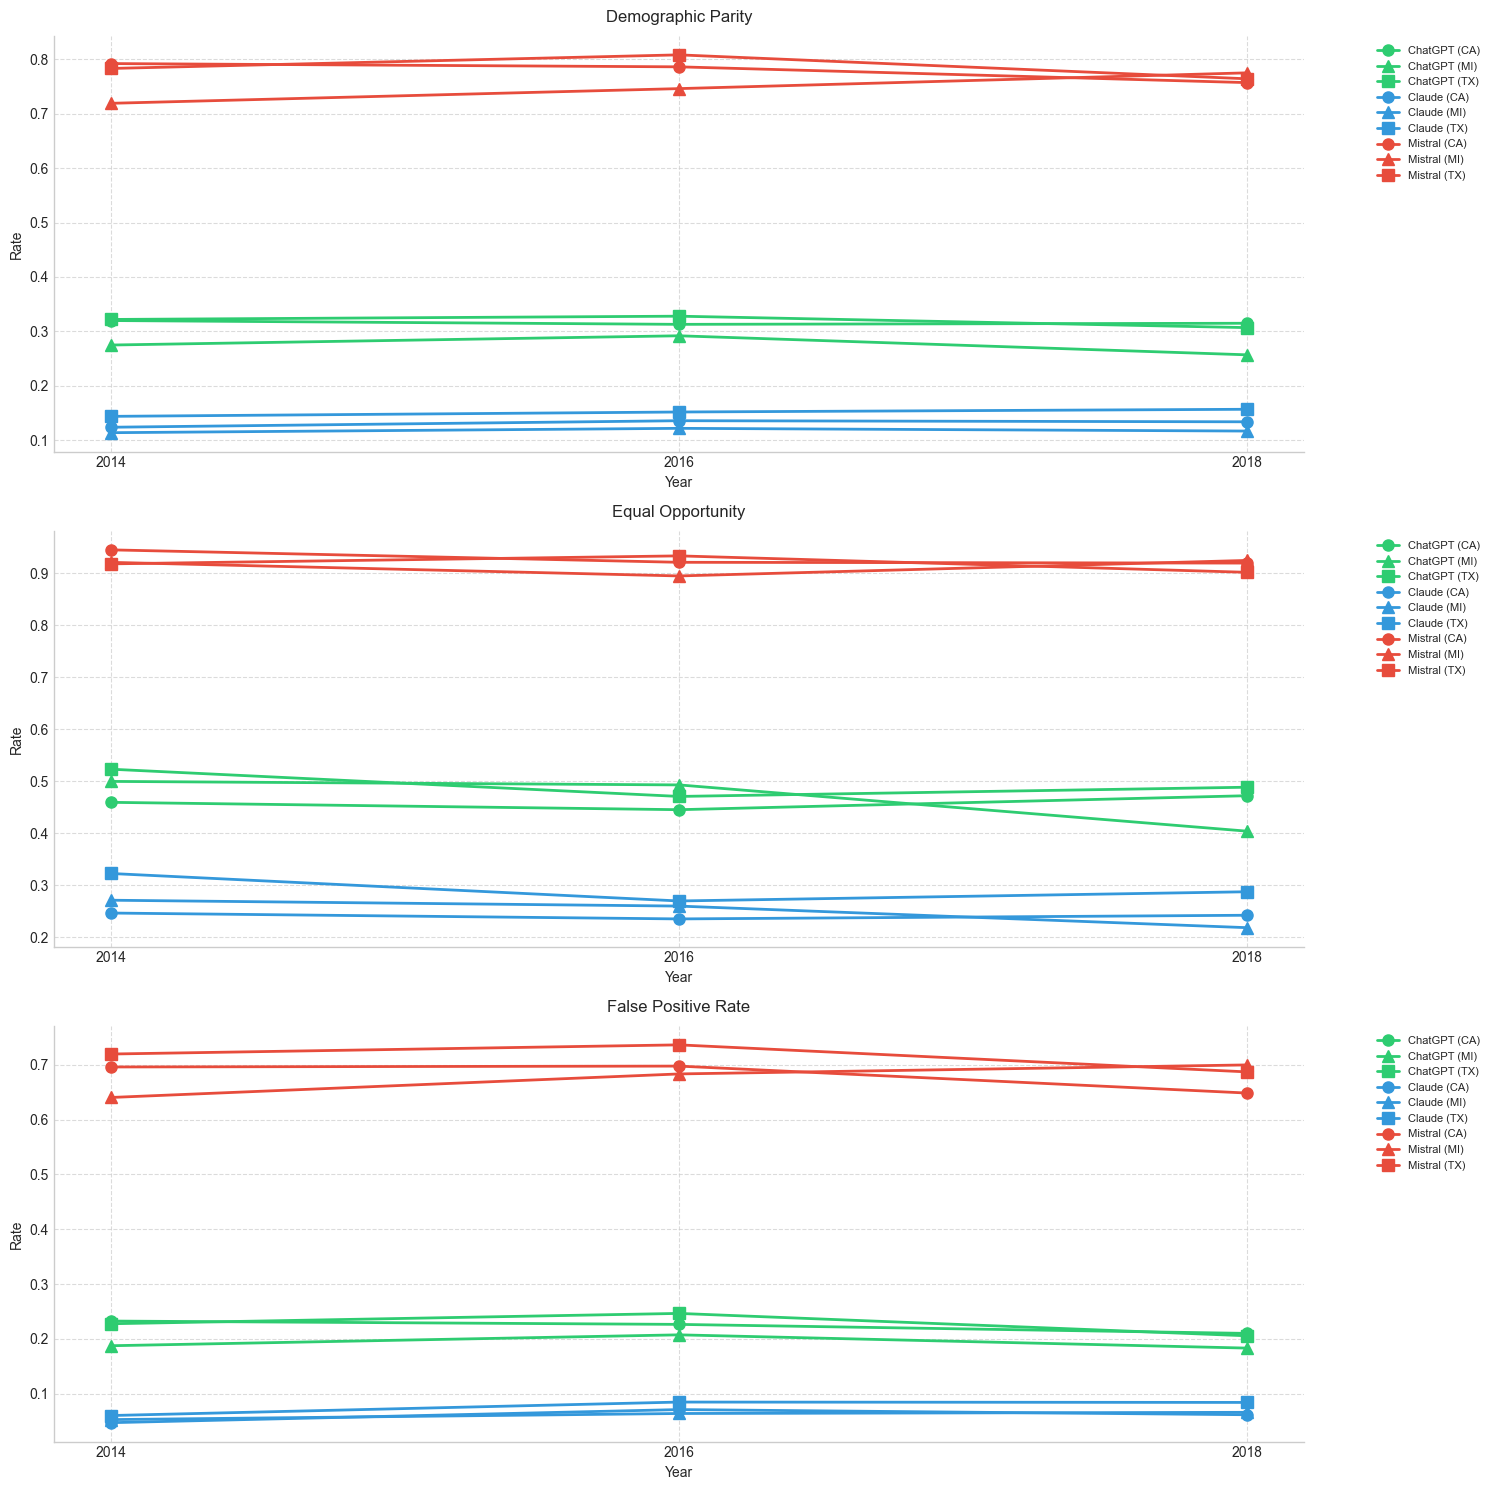


Summary Statistics by State:

Demographic Parity:

CA:
ChatGPT: 0.316
Claude: 0.131
Mistral: 0.778

MI:
ChatGPT: 0.275
Claude: 0.118
Mistral: 0.747

TX:
ChatGPT: 0.319
Claude: 0.151
Mistral: 0.785

Equal Opportunity:

CA:
ChatGPT: 0.459
Claude: 0.242
Mistral: 0.929

MI:
ChatGPT: 0.466
Claude: 0.250
Mistral: 0.914

TX:
ChatGPT: 0.494
Claude: 0.294
Mistral: 0.918

False Positive Rate:

CA:
ChatGPT: 0.223
Claude: 0.060
Mistral: 0.681

MI:
ChatGPT: 0.193
Claude: 0.061
Mistral: 0.674

TX:
ChatGPT: 0.227
Claude: 0.076
Mistral: 0.714


In [63]:
def plot_fairness_trends_by_state(fairness_metrics):
    metrics = ['demographic_parity', 'equal_opportunity', 'false_positive_rate']
    states_to_show = ['CA', 'MI', 'TX']
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    
    years = [2014, 2016, 2018]
    models = sorted(list(set(model for model, _, _ in fairness_metrics.keys())))
    
    colors = {
        'ChatGPT': '#2ecc71',
        'Claude': '#3498db',
        'Mistral': '#e74c3c'
    }
    
    markers = {
        'CA': 'o',
        'MI': '^',
        'TX': 's'
    }
    
    for idx, metric in enumerate(metrics):
        for model in models:
            for state in states_to_show:
                metric_values = []
                for year in years:
                    if (model, year, state) in fairness_metrics:
                        metric_values.append(fairness_metrics[(model, year, state)][metric])
                
                if metric_values:
                    axes[idx].plot(years, metric_values, 
                                 label=f'{model} ({state})',
                                 marker=markers[state],
                                 color=colors[model],
                                 linewidth=2,
                                 markersize=8)
        
        axes[idx].set_title(f'{metric.replace("_", " ").title()}', fontsize=12, pad=10)
        axes[idx].set_xlabel('Year', fontsize=10)
        axes[idx].set_ylabel('Rate', fontsize=10)
        axes[idx].grid(True, linestyle='--', alpha=0.7)
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axes[idx].set_xticks(years)
        
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    print("\nSummary Statistics by State:")
    for metric in metrics:
        print(f"\n{metric.replace('_', ' ').title()}:")
        for state in states_to_show:
            print(f"\n{state}:")
            for model in models:
                values = []
                for year in years:
                    if (model, year, state) in fairness_metrics:
                        values.append(fairness_metrics[(model, year, state)][metric])
                if values:
                    print(f"{model}: {np.mean(values):.3f}")

plot_fairness_trends_by_state(fairness_metrics)